<a href="https://colab.research.google.com/github/kuNalsharma0725/Capstone-Project--AI_ML/blob/main/Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1.Load cleaned_data.csv from Part1

import pandas as pd
url='https://raw.githubusercontent.com/kuNalsharma0725/Capstone-Project--AI_ML/refs/heads/main/cleaned_data.csv'
df = pd.read_csv(url)
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [ ]:
#Drop the irrelevant column 'student_id'
df = df.drop('student_id', axis=1)
df.head(3)

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3


In [ ]:
#Splitting features and labels(both regression and classification)
y_reg = df['exam_score']
y_clf = df['extracurricular_participation']
X=df.drop(['exam_score','extracurricular_participation'],axis=1)

In [ ]:
#print the shape of features and labels
print(X.shape)
print(y_reg.shape)
print(y_clf.shape)

(1000, 13)
(1000,)
(1000,)


In [ ]:
#2.Label encoding for the target column
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_clf=le.fit_transform(y_clf)


In [ ]:
#Check label_encoding and value_counts
values, counts = np.unique(y_clf, return_counts=True)
print("Values:", values)
print("Counts:", counts)

Values: [0 1]
Counts: [682 318]


In [ ]:
#Orndinal encoding for categorical column(diet_quality)
from sklearn.preprocessing import OrdinalEncoder

# Define the explicit hierarchy (from lowest to highest)
order = ['Poor', 'Fair', 'Good']

# Initialize with the specific order
encoder = OrdinalEncoder(categories=[order])

# Fit and transform
X['diet_quality'] = encoder.fit_transform(X[['diet_quality']])



In [ ]:
#Orndinal encoding for categorical column(parental_education_level)
from sklearn.preprocessing import OrdinalEncoder

# Define the explicit hierarchy (from lowest to highest)
order = education_order = ['Unknown', 'High School', 'Bachelor', 'Master']

# Initialize with the specific order
encoder = OrdinalEncoder(categories=[order])

# Fit and transform
X['parental_education_level'] = encoder.fit_transform(X[['parental_education_level']])


In [ ]:
#Orndinal encoding for categorical column(internet_quality)
from sklearn.preprocessing import OrdinalEncoder

# Define the explicit hierarchy (from lowest to highest)
order = education_order = ['Poor', 'Average', 'Good']

# Initialize with the specific order
encoder = OrdinalEncoder(categories=[order])

# Fit and transform
X['internet_quality'] = encoder.fit_transform(X[['internet_quality']])

In [ ]:
#One-hot Encoding for categorical columns which have not order(gender, part_time_job)
X = pd.get_dummies(X, columns=['gender', 'part_time_job'], drop_first=True)

In [ ]:
#Dataframe after encoding
print(X.shape)
X.head()


(1000, 14)


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,gender_Male,gender_Other,part_time_job_Yes
0,23,0.0,1.2,1.1,85.0,8.0,1.0,6,3.0,1.0,8,False,False,False
1,20,6.9,2.8,2.3,97.3,4.6,2.0,6,1.0,1.0,8,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,0.0,1,1.0,0.0,1,True,False,False
3,23,1.0,3.9,1.0,71.0,9.2,0.0,4,3.0,2.0,1,False,False,False
4,19,5.0,4.4,0.5,90.9,4.9,1.0,3,3.0,2.0,1,False,False,False


In [ ]:
#3.Leak-free train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(X, y_reg, y_clf, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_reg_train.shape)
print(y_reg_test.shape)
print(y_clf_train.shape)
print(y_clf_test.shape)

(800, 14)
(200, 14)
(800,)
(200,)
(800,)
(200,)


In [ ]:
#Standard Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled)
print(X_test_scaled)

[[-0.210232   -1.04978529  0.6126009  ... -0.93933644 -0.21389632
   1.91080161]
 [ 0.65894423  1.91518641  1.46938539 ... -0.93933644 -0.21389632
   1.91080161]
 [-0.210232   -0.71285669 -0.50121892 ... -0.93933644 -0.21389632
  -0.52334057]
 ...
 [-0.210232    0.02838623  1.21235004 ... -0.93933644 -0.21389632
  -0.52334057]
 [ 1.52812047 -1.04978529 -2.12910944 ...  1.06458129 -0.21389632
  -0.52334057]
 [-1.07940824  0.50008628  1.29802849 ...  1.06458129 -0.21389632
  -0.52334057]]
[[ 1.09353235 -0.03899949 -0.32986203 ...  1.06458129 -0.21389632
  -0.52334057]
 [ 0.22435612  1.5782578   1.81209918 ...  1.06458129 -0.21389632
   1.91080161]
 [ 1.09353235  0.63485772 -0.07282668 ... -0.93933644 -0.21389632
   1.91080161]
 ...
 [ 0.65894423 -0.51069953 -1.10096806 ...  1.06458129 -0.21389632
   1.91080161]
 [-1.07940824  0.16315768 -1.61503875 ... -0.93933644 -0.21389632
  -0.52334057]
 [ 1.09353235  0.567472   -0.41554047 ... -0.93933644 -0.21389632
   1.91080161]]


In [ ]:
#4. Regression model: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Train the model
model_reg = LinearRegression()
model_reg.fit(X_train_scaled, y_reg_train)

LinearRegression()

In [ ]:
#Predict the values
y_reg_pred = model_reg.predict(X_test_scaled)
y_reg_pred[:5]


array([65.89047147, 74.85648826, 78.59489665, 73.83738834, 61.32904984])

In [ ]:
#compute mean_squared_error
MSE_lin=mean_squared_error(y_reg_test, y_reg_pred)
MSE_lin

25.915133655053523

In [ ]:
#Compute r2_score
r2_lin=r2_score(y_reg_test, y_reg_pred)
r2_lin

0.8989384041854067

In [ ]:
#model's coefficients alongside the corresponding feature names.
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_reg.coef_
})
coeff_df['Absolute_Coefficient'] = coeff_df['Coefficient'].abs()
print(coeff_df[['Feature', 'Coefficient']].to_string(index=False))

                 Feature  Coefficient
                     age     0.123669
     study_hours_per_day    14.164068
      social_media_hours    -3.155314
           netflix_hours    -2.530613
   attendance_percentage     1.375647
             sleep_hours     2.417247
            diet_quality    -0.231459
      exercise_frequency     2.652493
parental_education_level     0.083657
        internet_quality    -0.080475
    mental_health_rating     5.570824
             gender_Male     0.057202
            gender_Other     0.150718
       part_time_job_Yes     0.160417


In [ ]:
#three features with the largest absolute coefficient values
top_3_features = coeff_df.nlargest(3, 'Absolute_Coefficient')
print(top_3_features[['Feature', 'Coefficient', 'Absolute_Coefficient']].to_string(index=False))

             Feature  Coefficient  Absolute_Coefficient
 study_hours_per_day    14.164068             14.164068
mental_health_rating     5.570824              5.570824
  social_media_hours    -3.155314              3.155314


In [ ]:
# Apply Ridge Regression
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_reg_train)
train_MSE=mean_squared_error(y_reg_train, ridge_model.predict(X_train_scaled))
test_MSE=mean_squared_error(y_reg_test, ridge_model.predict(X_test_scaled))
train_r2=r2_score(y_reg_train, ridge_model.predict(X_train_scaled))
test_r2=r2_score(y_reg_test, ridge_model.predict(X_test_scaled))

In [ ]:
#Compare MSE and R²
print(f'Linear Regression MSE: {MSE_lin}')
print(f'Ridge Regression  MSE: {test_MSE}')
print(f'Linear Regression R²:  {r2_lin}')
print(f'Ridge Regression  R²:  {test_r2}')


Linear Regression MSE: 25.915133655053523
Ridge Regression  MSE: 25.92794041758806
Linear Regression R²:  0.8989384041854067
Ridge Regression  R²:  0.8988884614810323


In [ ]:
#5. Classification model — Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



In [ ]:
#Value_counts of y_clf_train
values, counts = np.unique(y_clf_train, return_counts=True)
print("Values:", values)
print("Counts:", counts)

Values: [0 1]
Counts: [542 258]


* Here no class has fewer than 35% of samples, so here  no need of handling the imbalance.

*  But we choose class_weight='balanced' because the model to pay equal attention to both classes, preventing it from being biased toward the majority class.



In [ ]:
#Train Regression model
model_clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_clf.fit(X_train_scaled, y_clf_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
#Predict the values
y_clf_pred = model_clf.predict(X_test_scaled)


In [ ]:
#Compute and report the matrix
cm = confusion_matrix(y_clf_test, y_clf_pred)
cm

array([[73, 67],
       [39, 21]])

In [ ]:
report = classification_report(y_clf_test, y_clf_pred)
print(report)

              precision    recall  f1-score   support

           0       0.65      0.52      0.58       140
           1       0.24      0.35      0.28        60

    accuracy                           0.47       200
   macro avg       0.45      0.44      0.43       200
weighted avg       0.53      0.47      0.49       200



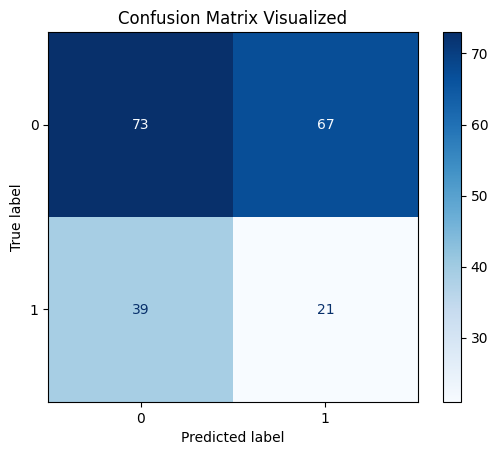

In [ ]:
#Display confusion matrix
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Visualized")
plt.show()

In [ ]:
#Compute roc_auc
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_clf_test, y_clf_pred)
auc_value = roc_auc_score(y_clf_test, y_clf_pred)
auc_value

np.float64(0.43571428571428567)

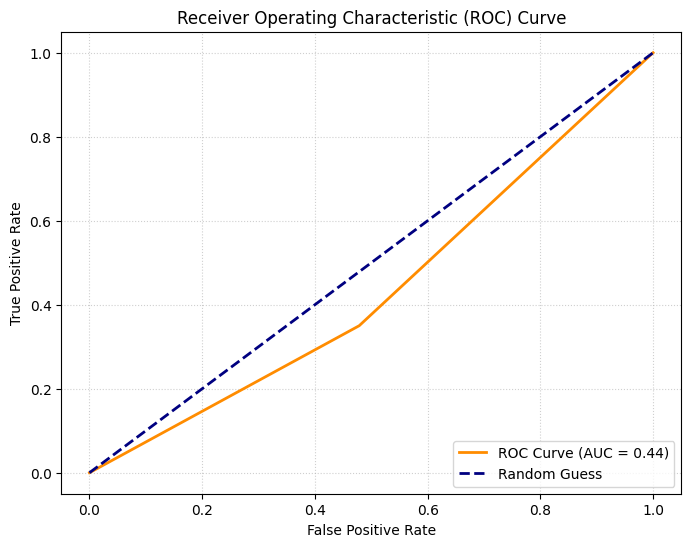

In [ ]:
#plot roc curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
#Decision-threshold sensitivity
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute metrics at each threshold
thresholds = np.arange(0.30, 0.80, 0.10)
results = []
for t in thresholds:

    # Calculate metrics (zero_division handling prevents warnings if a class is unpredicted)
    precision = precision_score(y_clf_test, y_clf_pred, zero_division=0)
    recall = recall_score(y_clf_test, y_clf_pred, zero_division=0)
    f1 = f1_score(y_clf_test, y_clf_pred, zero_division=0)

    results.append({
        "Threshold": round(t, 2),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4)
    })

# Display the results
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Threshold  Precision  Recall     F1
       0.3     0.2386    0.35 0.2838
       0.4     0.2386    0.35 0.2838
       0.5     0.2386    0.35 0.2838
       0.6     0.2386    0.35 0.2838
       0.7     0.2386    0.35 0.2838


In [ ]:
# 6.Regularization experiment on Logistic Regression
#Train second model
second_model = LogisticRegression(C=0.01, penalty='l2', solver='liblinear',max_iter=1000, random_state=42,class_weight='balanced')
second_model.fit(X_train_scaled, y_clf_train)


LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')

In [ ]:
second_model_pred = second_model.predict(X_test_scaled)
y_second_pred = second_model.predict_proba(X_test_scaled)

In [ ]:
# Calculate the metrics
precision = precision_score(y_clf_test, second_model_pred)
recall = recall_score(y_clf_test, second_model_pred)

# For AUC, we use the predicted probabilities of the positive class (column 1)
auc = roc_auc_score(y_clf_test, y_second_pred[:, 1])

#Create the DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'AUC'],
    'Value': [precision, recall, auc]
})

# Display the DataFrame
print(metrics_df)

      Metric     Value
0  Precision  0.235955
1     Recall  0.350000
2        AUC  0.416786


In [ ]:
#Bootstrap confidence interval for AUC difference
np.random.seed(42)

# Configuration
n_iterations = 500
auc_differences = []
n_samples = len(y_clf_test)

# Extract the positive class probabilities for both models
prob_c01 = y_second_pred # for second model
prob_c10= model_clf.predict_proba(X_test_scaled)   # for first model

# Run bootstrap resampling
for i in range(n_iterations):
    # 1. Sample row indices with replacement
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)

    # 2. Index into the true labels and predicted probabilities
    y_boot = y_clf_test[boot_indices]
    prob_c01_boot = prob_c01[boot_indices]
    prob_c10_boot = prob_c10[boot_indices]

    # Check to handle edge cases where a bootstrap sample might contain only one class
    if len(np.unique(y_boot)) < 2:
        continue

    # 3. Compute AUC for both models on the bootstrap sample
    auc_c01 = roc_auc_score(y_boot, prob_c01_boot[:, 1])
    auc_c10 = roc_auc_score(y_boot, prob_c10_boot[:, 1])

    # 4. Compute the difference (C=1.0 minus C=0.01)
    auc_diff = auc_c10 - auc_c01
    auc_differences.append(auc_diff)

# Convert to a numpy array for statistical calculations
auc_differences = np.array(auc_differences)

# 5. Compute mean and percentiles
mean_diff = np.mean(auc_differences)
lower_percentile = np.percentile(auc_differences, 2.5)
upper_percentile = np.percentile(auc_differences, 97.5)

# Output results
print(f"Mean AUC Difference (C=1.0 - C=0.01): {mean_diff:.4f}")
print(f"95% Bootstrap Confidence Interval: [{lower_percentile:.4f}, {upper_percentile:.4f}]")

Mean AUC Difference (C=1.0 - C=0.01): 0.0008
95% Bootstrap Confidence Interval: [-0.0058, 0.0080]


In [ ]:
#Save and download the scaling dataset for part 3
X.to_csv('scaled_data.csv', index=False)
from google.colab import files
files.download('scaled_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
y_clf_df = pd.DataFrame(y_clf)
y_clf_df.to_csv('y_clf.csv', index=False)

# 3. Download the file
files.download('y_clf.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>